In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time

# Automated histogram plot settings
xmin, xmax = -10, 10
num_bins = 100

def plot_histogram(counts, xmin=xmin, xmax=xmax, num_bins=num_bins):
    # Map bin counts to x-range [-10, 10]
    bin_width = (xmax - xmin) / num_bins
    x_left_edges = [xmin + i * bin_width for i in range(num_bins)]

    plt.figure(figsize=(10, 4))
    plt.bar(x_left_edges, counts, width=bin_width, align="edge", edgecolor="black")
    plt.xlim(xmin, xmax)
    plt.title(f"Histogram (x from {xmin} to {xmax}, {num_bins} bins)")
    plt.xlabel("x")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


# Threading

Time taken with 1 threads: 3.3997 seconds
Time taken with 2 threads: 1.3549 seconds
Time taken with 4 threads: 0.9984 seconds
Time taken with 8 threads: 0.7875 seconds
Time taken with 16 threads: 0.9062 seconds
Time taken with 32 threads: 0.7318 seconds


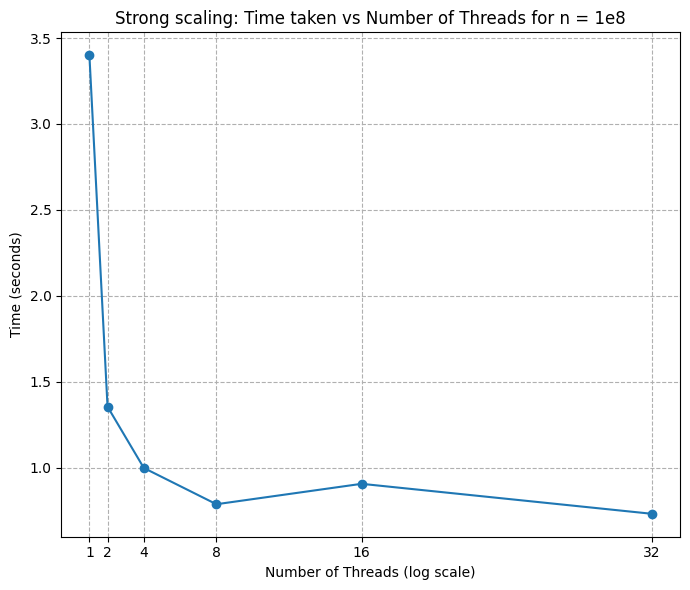

In [ ]:
import thread_lorentz 
#Strong Scaling
n=1e8
times=[]
thread_counts = [1, 2, 4, 8, 16, 32]
for n_threads in thread_counts:
    start_time = time.perf_counter()
    local_counts,cnt = thread_lorentz.run_threaded(n, n_threads=n_threads)
    end_time = time.perf_counter()
    thread_time =  end_time - start_time
    times.append(thread_time)
    print(f"Time taken with {cnt} threads: {end_time - start_time:.4f} seconds")


#plot_histogram(local_counts)

plt.figure(figsize=(7, 6))
plt.plot(thread_counts, times, marker='o')
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Strong scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

In [4]:
#Weak Scaling
n=1e8
times=[]
thread_counts = [1, 2, 4, 8, 16]
for n_threads in thread_counts:
    start_time = time.perf_counter()
    local_counts,cnt = thread_lorentz.run_threaded(n*n_threads, n_threads=n_threads)
    end_time = time.perf_counter()
    thread_time =  end_time - start_time
    times.append(thread_time/n_threads)  # Normalize by number of threads for weak scaling
    print(f"Time taken with {cnt} threads: {end_time - start_time:.4f} seconds")


#plot_histogram(local_counts)

plt.figure(figsize=(7, 6))
plt.plot(thread_counts, times, marker='o')
plt.xlabel('n_threads')
plt.ylabel('Time/n_threads (seconds)')
plt.title(f'Weak scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

Time taken with 1 threads: 3.0236 seconds
Time taken with 2 threads: 4.3711 seconds


KeyboardInterrupt: 

# Multiprocessing module

Time taken with 1 threads: 2.2007 seconds
Time taken with 2 threads: 1.2543 seconds
Time taken with 4 threads: 0.9085 seconds
Time taken with 8 threads: 0.9190 seconds
Time taken with 16 threads: 1.0898 seconds


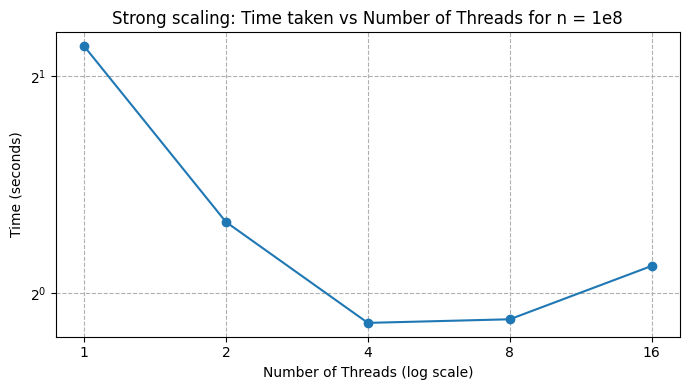

In [5]:
import mp_lorentz

import matplotlib.pyplot as plt

#Strong Scaling
n=1e8
times=[]
thread_counts = [1, 2, 4, 8, 16]
for n_threads in thread_counts:
    start_time = time.perf_counter()
    local_counts = mp_lorentz.run_multiproc(n, n_cores=n_threads)
    end_time = time.perf_counter()
    thread_time =  end_time - start_time
    times.append(thread_time)
    print(f"Time taken with {n_threads} threads: {end_time - start_time:.4f} seconds")


#plot_histogram(local_counts)

plt.figure(figsize=(7, 4))
plt.plot(thread_counts, times, marker='o')
plt.xscale('log', base=2)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Strong scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

In [ ]:
#Weak Scaling
n=1e8
times=[]
thread_counts = [1, 2, 4, 8, 16]
for n_threads in thread_counts:
    start_time = time.perf_counter()
    local_counts = mp_lorentz.run_multiproc(n*n_threads, n_cores=n_threads)
    end_time = time.perf_counter()
    thread_time =  end_time - start_time
    times.append(thread_time)
    print(f"Time taken with {n_threads} threads: {end_time - start_time:.4f} seconds")


#plot_histogram(local_counts)

plt.figure(figsize=(7, 4))
plt.plot(thread_counts, times, marker='o')
plt.xscale('log', base=2)
plt.yscale('log', base=2)
plt.xlabel('Number of Threads (log scale)')
plt.ylabel('Time (seconds)')
plt.title(f'Weak scaling: Time taken vs Number of Threads for n = 1e{int(np.log10(n))}')
plt.grid(True, which="both", ls="--")
plt.xticks(thread_counts, thread_counts)
plt.tight_layout()
plt.show()

Time taken with 1 threads: 2.9567 seconds
Time taken with 2 threads: 3.9009 seconds
Time taken with 4 threads: 48.6194 seconds
